# Dissertation Figure Design: Gaussian Controls

This notebook loads a frozen prediction cache and performs no model inference.

**Columns:** Exact GP, Gaussian TNP, Dropout CRPS-TNP, StochLN CRPS-TNP.

**Rows:**
- Direct one-shot predictive samples.
- AR-conditioned mean paths.

For the lower row, each path is formed by sampling sparse support values
autoregressively, appending them to the context, and evaluating the resulting
conditional predictive mean on a dense grid.

The top-row shaded band is a direct predictive interval. The lower-row shaded
band is an envelope across AR-conditioned mean paths; it is not itself a
predictive interval.

In [25]:
# Imports and repository location
%matplotlib inline

from pathlib import Path
import json
import string

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import Image, display


def find_repo_root(start: Path) -> Path:
    """Find the tnp-crps repository whether Jupyter starts in root or notebooks/."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "external" / "tnp").is_dir()
            and (candidate / "tnp_crps").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the tnp-crps repository from "
        f"{start}. Start Jupyter inside /scratch2/ij292/tnp-crps."
    )


REPO_ROOT = find_repo_root(Path.cwd())

torch.set_grad_enabled(False)

print("Repository root:", REPO_ROOT)
print("PyTorch version:", torch.__version__)

Repository root: /scratch2/ij292/tnp-crps
PyTorch version: 2.11.0+cu128


In [37]:
# All visual settings

# ---------------------------------------------------------------------
# Files
# ---------------------------------------------------------------------

CACHE_PATH = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "gaussian_controls"
    / "matern32_cache_v1.pt"
)

OUTPUT_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "gaussian_controls"
    / "notebook_exports"
)

EXPORT_NAME = "gaussian_controls_direct_vs_ar_v01"


# ---------------------------------------------------------------------
# Figure structure
# ---------------------------------------------------------------------

FIGSIZE = (9.6, 4.8)
DPI = 500

VISIBLE_PATHS = 8
PATH_START_INDEX = 0

INTERVAL_LEVEL = 0.90

SHOW_PATHS = True
SHOW_DIRECT_MEAN = True
SHOW_AR_MEAN = True

SHOW_DIRECT_INTERVAL = True
SHOW_AR_ENVELOPE = True

SHOW_LATENT_TRUTH = True
SHOW_CONTEXT = True
SHOW_TARGETS = False

SHOW_PANEL_LETTERS = True
SHOW_AR_ANCHOR_RUG = False

SHADE_CONTEXT_DOMAIN = False
CONTEXT_DOMAIN = (-2.0, 2.0)


# ---------------------------------------------------------------------
# Limits and ticks
# ---------------------------------------------------------------------

MANUAL_X_LIM = (-4.0, 4.0)

# Leave as None to calculate one shared limit from every panel.
MANUAL_Y_LIM = None

X_TICKS = (-4.0, -2.0, 0.0, 2.0, 4.0)

# Leave as None for automatic y ticks.
Y_TICKS = None

Y_PADDING_FRACTION = 0.07


# ---------------------------------------------------------------------
# Line and marker formatting
# ---------------------------------------------------------------------

PATH_ALPHA = 0.30
PATH_LINEWIDTH = 0.80

MEAN_LINEWIDTH = 1.45

TRUTH_LINEWIDTH = 1.05
TRUTH_LINESTYLE = (0, (4, 2))

DIRECT_INTERVAL_ALPHA = 0.12
AR_ENVELOPE_ALPHA = 0.09

CONTEXT_MARKER_SIZE = 9
CONTEXT_EDGE_WIDTH = 0.20
CONTEXT_ALPHA = 0.82

TARGET_MARKER_SIZE = 7
TARGET_ALPHA = 0.30

AXIS_LINEWIDTH = 0.65
TICK_LABEL_SIZE = 8.5
COLUMN_TITLE_SIZE = 11.5
ROW_LABEL_SIZE = 10.0
AXIS_LABEL_SIZE = 9.5
LEGEND_SIZE = 10.5
PANEL_LETTER_SIZE = 8.2


# ---------------------------------------------------------------------
# Colour system
# ---------------------------------------------------------------------

# Set False to draw every prediction in one shared purple.
USE_MODEL_COLOURS = True

SINGLE_PREDICTION_COLOUR = "#5B4B8A"

MODEL_COLOURS = {
    "Exact GP oracle": "#657A86",       # blue-grey
    "Gaussian TNP": "#3E6FA8",          # restrained blue
    "Dropout CRPS-TNP": "#79589C",      # restrained purple
    "StochLN CRPS-TNP": "#2F7C78",      # restrained teal
}

TRUTH_COLOUR = "#303030"
CONTEXT_COLOUR = "#111111"
TARGET_COLOUR = "#A84A4A"
CONTEXT_DOMAIN_COLOUR = "#F2F2F2"


# ---------------------------------------------------------------------
# Labels
# ---------------------------------------------------------------------

COLUMN_ORDER = [
    "Exact GP oracle",
    "Gaussian TNP",
    "Dropout CRPS-TNP",
    "StochLN CRPS-TNP",
]

COLUMN_TITLES = {
    "Exact GP oracle": "Exact GP",
    "Gaussian TNP": "Gaussian TNP",
    "Dropout CRPS-TNP": "Dropout CRPS-TNP",
    "StochLN CRPS-TNP": "StochLN CRPS-TNP",
}

ROW_SPECS = [
    ("direct", "Direct"),
    ("ar", "AR-conditioned\nmean paths"),
]


# ---------------------------------------------------------------------
# Dissertation-wide Matplotlib base style
# ---------------------------------------------------------------------

DISSERTATION_RC = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.linewidth": AXIS_LINEWIDTH,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
    "xtick.major.width": 0.65,
    "ytick.major.width": 0.65,
    "xtick.major.size": 3.4,
    "ytick.major.size": 3.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}

In [27]:
# Load and validate the cache

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cache not found:\n{CACHE_PATH}\n\n"
        "Run experiments/cache_gaussian_controls_figure.py first."
    )

cache = torch.load(
    CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

required_top_level = {
    "metadata",
    "task",
    "exact_gp",
    "models",
}

missing_top_level = required_top_level.difference(cache)

if missing_top_level:
    raise KeyError(
        f"Cache is missing top-level keys: {sorted(missing_top_level)}"
    )

expected_models = set(COLUMN_ORDER[1:])
cached_models = set(cache["models"])

if cached_models != expected_models:
    raise RuntimeError(
        "Unexpected cached models.\n"
        f"Expected: {sorted(expected_models)}\n"
        f"Found:    {sorted(cached_models)}"
    )

assert cache["task"]["xc"].shape[0] == 1
assert cache["task"]["yc"].shape[0] == 1
assert cache["task"]["x_plot"].shape[0] == 1
assert cache["task"]["latent_truth"].shape == cache["task"]["x_plot"].shape

assert cache["exact_gp"]["direct_samples"].ndim == 4

for model_name in COLUMN_ORDER[1:]:
    model_cache = cache["models"][model_name]

    for key in (
        "direct_samples",
        "ar_support_x",
        "raw_ar_samples",
        "ar_denoised_paths",
    ):
        if key not in model_cache:
            raise KeyError(
                f"{model_name} is missing cache entry {key!r}."
            )

    assert model_cache["direct_samples"].ndim == 4
    assert model_cache["raw_ar_samples"].ndim == 4
    assert model_cache["ar_denoised_paths"].ndim == 4


print("Cache metadata:")
print(json.dumps(cache["metadata"], indent=2))

print()
print("Task shapes:")
print("  xc:", tuple(cache["task"]["xc"].shape))
print("  yc:", tuple(cache["task"]["yc"].shape))
print("  x_plot:", tuple(cache["task"]["x_plot"].shape))
print("  latent_truth:", tuple(cache["task"]["latent_truth"].shape))

print()
print("Prediction shapes:")
print(
    "  Exact GP direct:",
    tuple(cache["exact_gp"]["direct_samples"].shape),
)

for model_name in COLUMN_ORDER[1:]:
    print(f"  {model_name}:")
    print(
        "    direct:",
        tuple(cache["models"][model_name]["direct_samples"].shape),
    )
    print(
        "    raw AR:",
        tuple(cache["models"][model_name]["raw_ar_samples"].shape),
    )
    print(
        "    AR-conditioned:",
        tuple(cache["models"][model_name]["ar_denoised_paths"].shape),
    )

Cache metadata:
{
  "config": "/scratch2/ij292/tnp-crps/experiments/configs/evaluation/gaussian_controls_final.yml",
  "eval_set": "matern32",
  "kernel": "matern32_kernel",
  "selected_generator_batch_index": 0,
  "num_context": 24,
  "num_ar_anchors": 32,
  "target_order": "ascending",
  "stochln_noise_mode": "refresh",
  "lower_row_semantics": "AR support samples followed by dense conditional predictive means"
}

Task shapes:
  xc: (1, 24, 1)
  yc: (1, 24, 1)
  x_plot: (1, 401, 1)
  latent_truth: (1, 401, 1)

Prediction shapes:
  Exact GP direct: (64, 1, 401, 1)
  Gaussian TNP:
    direct: (64, 1, 401, 1)
    raw AR: (32, 1, 32, 1)
    AR-conditioned: (32, 1, 401, 1)
  Dropout CRPS-TNP:
    direct: (64, 1, 401, 1)
    raw AR: (32, 1, 32, 1)
    AR-conditioned: (32, 1, 401, 1)
  StochLN CRPS-TNP:
    direct: (64, 1, 401, 1)
    raw AR: (32, 1, 32, 1)
    AR-conditioned: (32, 1, 401, 1)


In [28]:
# Cache access and summary helpers

STANDARD_NORMAL = torch.distributions.Normal(
    torch.tensor(0.0),
    torch.tensor(1.0),
)


def to_1d_cpu(value: torch.Tensor) -> torch.Tensor:
    return value.detach().cpu().reshape(-1)


def model_colour(model_name: str) -> str:
    if USE_MODEL_COLOURS:
        return MODEL_COLOURS[model_name]

    return SINGLE_PREDICTION_COLOUR


def panel_samples(
    cache: dict,
    model_name: str,
    row_key: str,
) -> torch.Tensor:
    """Return [M, 1, Nplot, 1] samples/paths for a panel."""
    if model_name == "Exact GP oracle":
        # Repeated as an oracle reference in the lower-left panel.
        return cache["exact_gp"]["direct_samples"]

    if row_key == "direct":
        return cache["models"][model_name]["direct_samples"]

    if row_key == "ar":
        return cache["models"][model_name]["ar_denoised_paths"]

    raise ValueError(f"Unknown row_key={row_key!r}.")


def central_interval(
    paths: torch.Tensor,
    level: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Pointwise empirical central interval over first dimension."""
    lower_probability = (1.0 - level) / 2.0
    upper_probability = 1.0 - lower_probability

    lower = torch.quantile(
        paths,
        lower_probability,
        dim=0,
    )

    upper = torch.quantile(
        paths,
        upper_probability,
        dim=0,
    )

    return lower, upper


def panel_summary(
    cache: dict,
    model_name: str,
    samples: torch.Tensor,
    interval_level: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return mean, lower and upper summaries on the dense grid."""
    if model_name == "Exact GP oracle":
        mean = cache["exact_gp"]["mean"][0, :, 0]
        scale = cache["exact_gp"]["scale"][0, :, 0]

        z_value = STANDARD_NORMAL.icdf(
            torch.tensor(
                0.5 + interval_level / 2.0,
                dtype=mean.dtype,
            )
        )

        lower = mean - z_value * scale
        upper = mean + z_value * scale

        return mean, lower, upper

    paths = samples[:, 0, :, 0]

    mean = paths.mean(dim=0)
    lower, upper = central_interval(
        paths,
        interval_level,
    )

    return mean, lower, upper


def select_visible_paths(
    paths: torch.Tensor,
) -> torch.Tensor:
    """Select a fixed, non-cherry-picked consecutive subset of paths."""
    num_available = int(paths.shape[0])
    num_visible = min(int(VISIBLE_PATHS), num_available)

    start = int(PATH_START_INDEX)

    if start < 0:
        raise ValueError("PATH_START_INDEX cannot be negative.")

    if start + num_visible > num_available:
        start = max(0, num_available - num_visible)

    return paths[start : start + num_visible]


def compute_shared_y_limits(
    cache: dict,
) -> tuple[float, float]:
    """Calculate common y limits from all displayed panels."""
    values = [
        to_1d_cpu(cache["task"]["latent_truth"]),
        to_1d_cpu(cache["task"]["yc"]),
    ]

    if SHOW_TARGETS:
        values.append(
            to_1d_cpu(cache["task"]["yt"])
        )

    for row_key, _ in ROW_SPECS:
        for model_name in COLUMN_ORDER:
            samples = panel_samples(
                cache,
                model_name,
                row_key,
            )

            paths = samples[:, 0, :, 0]
            visible = select_visible_paths(paths)

            mean, lower, upper = panel_summary(
                cache,
                model_name,
                samples,
                INTERVAL_LEVEL,
            )

            if SHOW_PATHS:
                values.append(
                    visible.reshape(-1)
                )

            if (
                row_key == "direct"
                and SHOW_DIRECT_MEAN
            ) or (
                row_key == "ar"
                and SHOW_AR_MEAN
            ):
                values.append(mean)

            if (
                row_key == "direct"
                and SHOW_DIRECT_INTERVAL
            ) or (
                row_key == "ar"
                and SHOW_AR_ENVELOPE
            ):
                values.extend([lower, upper])

    combined = torch.cat(
        [
            value.detach().cpu().reshape(-1)
            for value in values
        ]
    )

    combined = combined[
        torch.isfinite(combined)
    ]

    if combined.numel() == 0:
        raise RuntimeError(
            "No finite values were available for y limits."
        )

    y_min = float(combined.min())
    y_max = float(combined.max())

    data_range = max(
        y_max - y_min,
        0.25,
    )

    padding = (
        Y_PADDING_FRACTION
        * data_range
    )

    return (
        y_min - padding,
        y_max + padding,
    )

In [29]:
# Main reusable plotting function

def make_gaussian_controls_figure(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray]:
    """Render the dissertation 2x4 Gaussian-control comparison."""

    with mpl.rc_context(DISSERTATION_RC):
        fig, axes = plt.subplots(
            nrows=2,
            ncols=4,
            figsize=FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        x_plot = to_1d_cpu(
            cache["task"]["x_plot"][0, :, 0]
        ).numpy()

        latent_truth = to_1d_cpu(
            cache["task"]["latent_truth"][0, :, 0]
        ).numpy()

        xc = to_1d_cpu(
            cache["task"]["xc"][0, :, 0]
        ).numpy()

        yc = to_1d_cpu(
            cache["task"]["yc"][0, :, 0]
        ).numpy()

        xt_original = to_1d_cpu(
            cache["task"]["xt"][0, :, 0]
        ).numpy()

        yt_original = to_1d_cpu(
            cache["task"]["yt"][0, :, 0]
        ).numpy()

        x_limits = (
            tuple(MANUAL_X_LIM)
            if MANUAL_X_LIM is not None
            else (
                float(x_plot.min()),
                float(x_plot.max()),
            )
        )

        y_limits = (
            tuple(MANUAL_Y_LIM)
            if MANUAL_Y_LIM is not None
            else compute_shared_y_limits(cache)
        )

        for row_index, (
            row_key,
            row_title,
        ) in enumerate(ROW_SPECS):

            for column_index, model_name in enumerate(
                COLUMN_ORDER
            ):
                ax = axes[
                    row_index,
                    column_index,
                ]

                colour = model_colour(
                    model_name
                )

                samples = panel_samples(
                    cache,
                    model_name,
                    row_key,
                )

                paths = samples[
                    :,
                    0,
                    :,
                    0,
                ]

                visible_paths = select_visible_paths(
                    paths
                )

                mean, lower, upper = panel_summary(
                    cache,
                    model_name,
                    samples,
                    INTERVAL_LEVEL,
                )

                mean_np = to_1d_cpu(
                    mean
                ).numpy()

                lower_np = to_1d_cpu(
                    lower
                ).numpy()

                upper_np = to_1d_cpu(
                    upper
                ).numpy()

                if SHADE_CONTEXT_DOMAIN:
                    ax.axvspan(
                        CONTEXT_DOMAIN[0],
                        CONTEXT_DOMAIN[1],
                        facecolor=CONTEXT_DOMAIN_COLOUR,
                        edgecolor="none",
                        alpha=1.0,
                        zorder=-10,
                    )

                show_band = (
                    SHOW_DIRECT_INTERVAL
                    if row_key == "direct"
                    else SHOW_AR_ENVELOPE
                )

                if show_band:
                    band_alpha = (
                        DIRECT_INTERVAL_ALPHA
                        if row_key == "direct"
                        else AR_ENVELOPE_ALPHA
                    )

                    ax.fill_between(
                        x_plot,
                        lower_np,
                        upper_np,
                        color=colour,
                        alpha=band_alpha,
                        linewidth=0.0,
                        zorder=0,
                    )

                if SHOW_PATHS:
                    for visible_path in visible_paths:
                        ax.plot(
                            x_plot,
                            to_1d_cpu(
                                visible_path
                            ).numpy(),
                            color=colour,
                            alpha=PATH_ALPHA,
                            linewidth=PATH_LINEWIDTH,
                            zorder=1,
                        )

                show_mean = (
                    SHOW_DIRECT_MEAN
                    if row_key == "direct"
                    else SHOW_AR_MEAN
                )

                if show_mean:
                    ax.plot(
                        x_plot,
                        mean_np,
                        color=colour,
                        linewidth=MEAN_LINEWIDTH,
                        zorder=3,
                    )

                if SHOW_LATENT_TRUTH:
                    ax.plot(
                        x_plot,
                        latent_truth,
                        color=TRUTH_COLOUR,
                        linewidth=TRUTH_LINEWIDTH,
                        linestyle=TRUTH_LINESTYLE,
                        alpha=0.92,
                        zorder=4,
                    )

                if SHOW_CONTEXT:
                    ax.scatter(
                        xc,
                        yc,
                        s=CONTEXT_MARKER_SIZE,
                        facecolor=CONTEXT_COLOUR,
                        edgecolor="white",
                        linewidth=CONTEXT_EDGE_WIDTH,
                        alpha=CONTEXT_ALPHA,
                        zorder=6,
                    )

                if SHOW_TARGETS:
                    ax.scatter(
                        xt_original,
                        yt_original,
                        s=TARGET_MARKER_SIZE,
                        facecolor=TARGET_COLOUR,
                        edgecolor="none",
                        alpha=TARGET_ALPHA,
                        zorder=5,
                    )

                if (
                    row_key == "ar"
                    and model_name != "Exact GP oracle"
                    and SHOW_AR_ANCHOR_RUG
                ):
                    support_x = to_1d_cpu(
                        cache["models"][
                            model_name
                        ]["ar_support_x"][0, :, 0]
                    ).numpy()

                    ax.plot(
                        support_x,
                        np.full_like(
                            support_x,
                            0.025,
                        ),
                        linestyle="none",
                        marker="|",
                        markersize=4,
                        markeredgewidth=0.6,
                        color=colour,
                        alpha=0.40,
                        transform=ax.get_xaxis_transform(),
                        clip_on=False,
                        zorder=7,
                    )

                ax.set_xlim(*x_limits)
                ax.set_ylim(*y_limits)

                ax.grid(False)

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                for spine_name in (
                    "bottom",
                    "left",
                ):
                    ax.spines[
                        spine_name
                    ].set_linewidth(
                        AXIS_LINEWIDTH
                    )
                    ax.spines[
                        spine_name
                    ].set_color(
                        "#404040"
                    )

                ax.tick_params(
                    axis="both",
                    labelsize=TICK_LABEL_SIZE,
                    width=0.60,
                    length=3.0,
                    pad=1.5,
                )

                if X_TICKS is not None:
                    ax.set_xticks(
                        list(X_TICKS)
                    )

                if Y_TICKS is not None:
                    ax.set_yticks(
                        list(Y_TICKS)
                    )

                if row_index == 0:
                    ax.set_title(
                        COLUMN_TITLES[
                            model_name
                        ],
                        fontsize=COLUMN_TITLE_SIZE,
                        pad=5,
                    )

                    ax.tick_params(
                        labelbottom=False
                    )

                if column_index > 0:
                    ax.tick_params(
                        labelleft=False
                    )

                if (
                    column_index == 0
                ):
                    ax.set_ylabel(
                        r"$y$",
                        fontsize=AXIS_LABEL_SIZE,
                        labelpad=3,
                    )

                if SHOW_PANEL_LETTERS:
                    panel_index = (
                        row_index
                        * len(COLUMN_ORDER)
                        + column_index
                    )

                    ax.text(
                        0.025,
                        0.965,
                        string.ascii_lowercase[
                            panel_index
                        ],
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=PANEL_LETTER_SIZE,
                        fontweight="bold",
                        color="#202020",
                        zorder=10,
                    )

                if (
                    row_key == "ar"
                    and model_name
                    == "Exact GP oracle"
                ):
                    ax.text(
                        0.97,
                        0.04,
                        "oracle repeated",
                        transform=ax.transAxes,
                        ha="right",
                        va="bottom",
                        fontsize=8.0,
                        color="#505050",
                    )

        # Row labels.
        fig.text(
            0.020,
            0.705,
            "Direct",
            rotation=90,
            va="center",
            ha="center",
            fontsize=ROW_LABEL_SIZE,
        )

        fig.text(
            0.020,
            0.310,
            "AR-conditioned\nmean paths",
            rotation=90,
            va="center",
            ha="center",
            fontsize=ROW_LABEL_SIZE,
            linespacing=0.92,
        )

        # One global x label.
        fig.text(
            0.535,
            0.115,
            r"$x$",
            va="center",
            ha="center",
            fontsize=AXIS_LABEL_SIZE,
        )

        legend_handles = []

        if SHOW_LATENT_TRUTH:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=TRUTH_COLOUR,
                    linewidth=TRUTH_LINEWIDTH,
                    linestyle=TRUTH_LINESTYLE,
                    label="Latent truth",
                )
            )
        
        if SHOW_PATHS:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="#6A6A6A",
                    linewidth=PATH_LINEWIDTH,
                    alpha=0.75,
                    label="Paths",
                )
            )
        
        if (
            SHOW_DIRECT_MEAN
            or SHOW_AR_MEAN
        ):
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="#4A4A4A",
                    linewidth=MEAN_LINEWIDTH,
                    linestyle="-",
                    label="Mean",
                )
            )

        if (
            SHOW_DIRECT_INTERVAL
            or SHOW_AR_ENVELOPE
        ):
            legend_handles.append(
                Patch(
                    facecolor="#999999",
                    alpha=0.16,
                    edgecolor="none",
                    label="90% pointwise band",
                )
            )

        if SHOW_CONTEXT:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="none",
                    markerfacecolor=CONTEXT_COLOUR,
                    markeredgecolor="white",
                    markeredgewidth=CONTEXT_EDGE_WIDTH,
                    markersize=4.5,
                    label="Context observations",
                )
            )

        if SHOW_TARGETS:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="none",
                    markerfacecolor=TARGET_COLOUR,
                    markeredgecolor="none",
                    markersize=4,
                    alpha=TARGET_ALPHA,
                    label="Target observations",
                )
            )

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(
                0.535,
                0.005,
            ),
            ncol=min(
                len(legend_handles),
                5,
            ),
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.8,
            handletextpad=0.55,
            columnspacing=1.15,
        )

        fig.subplots_adjust(
            left=0.090,
            right=0.995,
            top=0.910,
            bottom=0.215,
            wspace=0.110,
            hspace=0.155,
        )

        return fig, axes

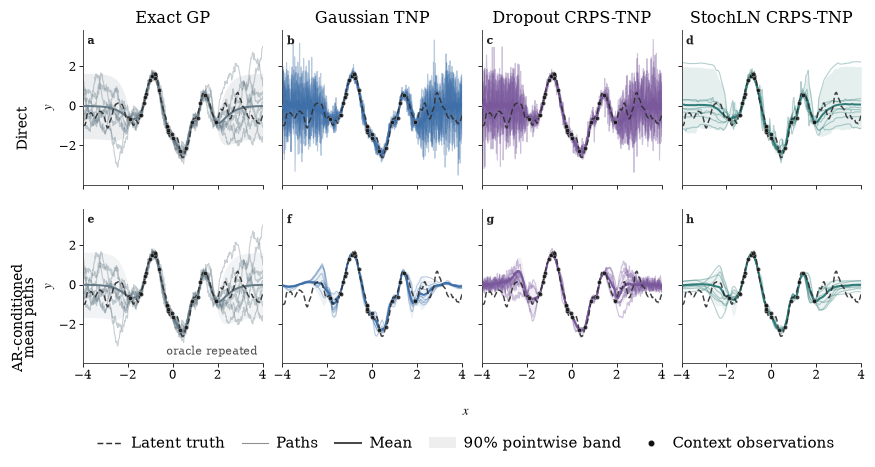

In [38]:
# Rapid iteration and preview

# ---------------------------------------------------------------------
# QUICK ITERATION CONTROLS
# ---------------------------------------------------------------------

VISIBLE_PATHS = 8

PATH_ALPHA = 0.36
PATH_LINEWIDTH = 0.80

SHOW_PATHS = True
SHOW_DIRECT_MEAN = True
SHOW_AR_MEAN = True

SHOW_DIRECT_INTERVAL = True
SHOW_AR_ENVELOPE = True

DIRECT_INTERVAL_ALPHA = 0.12
AR_ENVELOPE_ALPHA = 0.09

SHOW_CONTEXT = True
SHOW_TARGETS = False
SHOW_PANEL_LETTERS = True

USE_MODEL_COLOURS = True

FIGSIZE = (8.6, 4.8)

MANUAL_Y_LIM = None


fig, axes = make_gaussian_controls_figure(
    cache
)

plt.show()

Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/gaussian_controls/notebook_exports/gaussian_controls_direct_vs_ar_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/gaussian_controls/notebook_exports/gaussian_controls_direct_vs_ar_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/gaussian_controls/notebook_exports/gaussian_controls_direct_vs_ar_v01_style.json


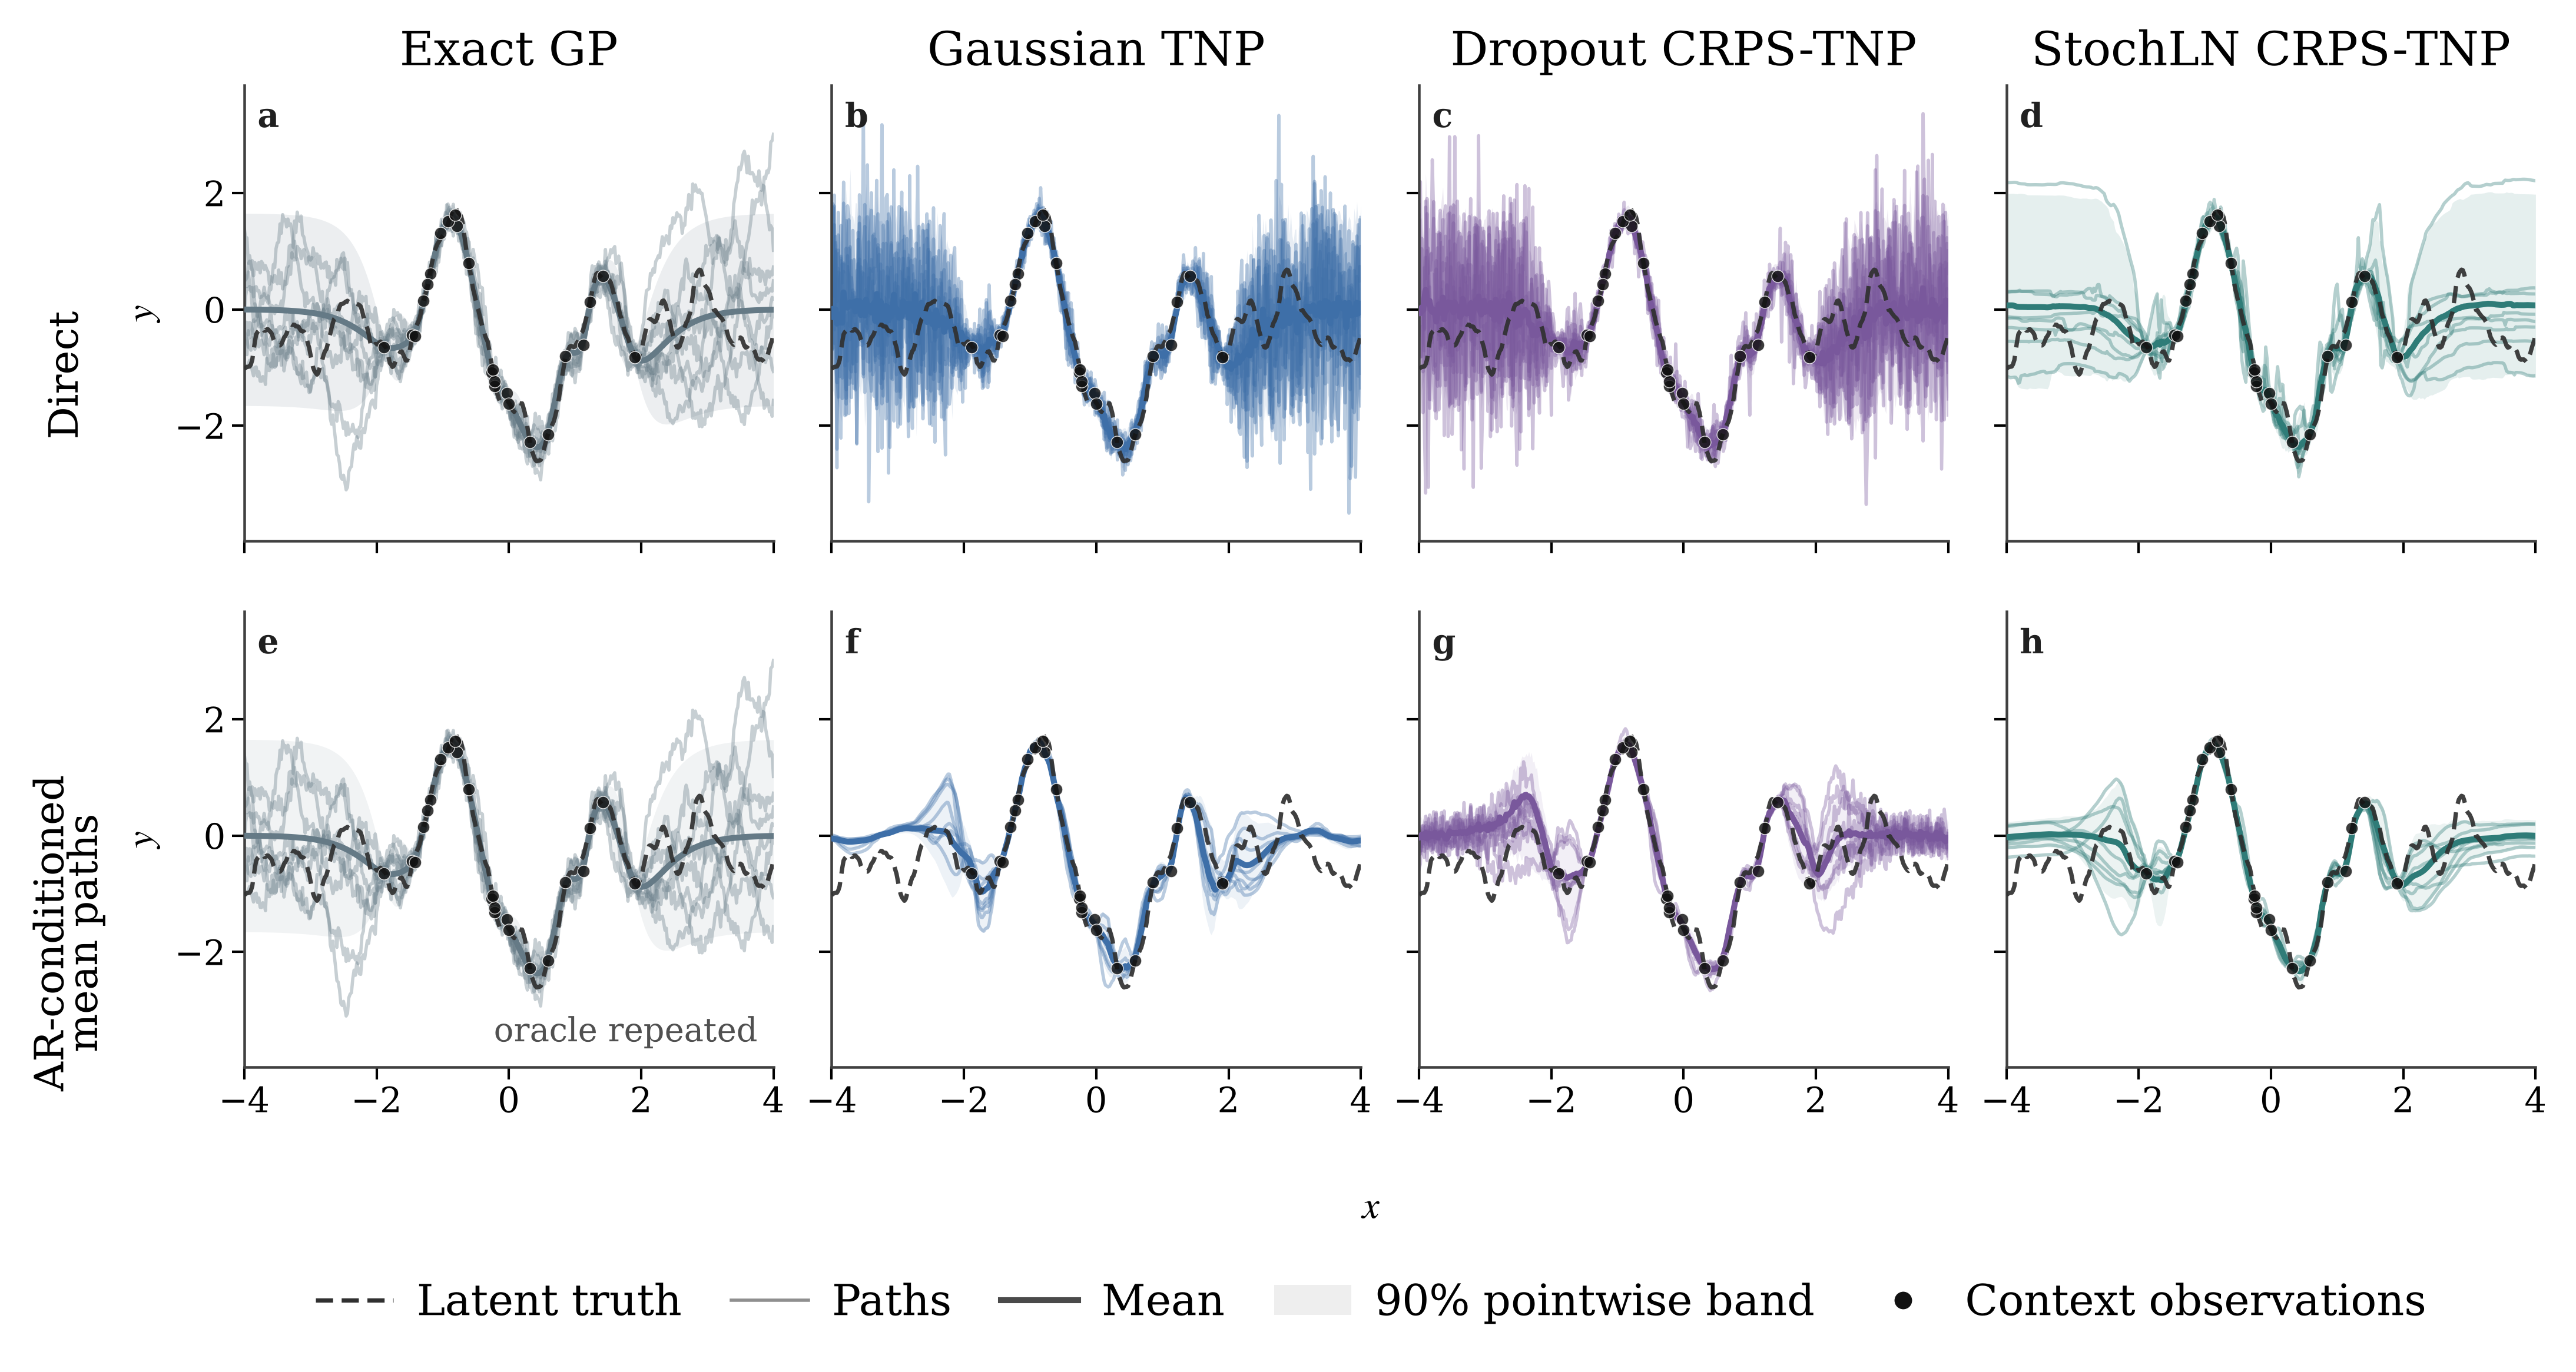

In [39]:
# Export PDF, PNG, and the style settings

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pdf_path = (
    OUTPUT_DIR
    / f"{EXPORT_NAME}.pdf"
)

png_path = (
    OUTPUT_DIR
    / f"{EXPORT_NAME}.png"
)

style_path = (
    OUTPUT_DIR
    / f"{EXPORT_NAME}_style.json"
)


fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
    metadata={
        "Title": "Gaussian controls: direct and AR-conditioned predictions",
        "Creator": "tnp-crps dissertation figure-design notebook",
    },
)

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white",
)


style_snapshot = {
    "cache_path": str(CACHE_PATH),
    "cache_metadata": cache["metadata"],
    "export_name": EXPORT_NAME,
    "figsize": list(FIGSIZE),
    "dpi": DPI,
    "visible_paths": VISIBLE_PATHS,
    "path_start_index": PATH_START_INDEX,
    "path_alpha": PATH_ALPHA,
    "path_linewidth": PATH_LINEWIDTH,
    "mean_linewidth": MEAN_LINEWIDTH,
    "truth_linewidth": TRUTH_LINEWIDTH,
    "interval_level": INTERVAL_LEVEL,
    "direct_interval_alpha": DIRECT_INTERVAL_ALPHA,
    "ar_envelope_alpha": AR_ENVELOPE_ALPHA,
    "show_paths": SHOW_PATHS,
    "show_direct_mean": SHOW_DIRECT_MEAN,
    "show_ar_mean": SHOW_AR_MEAN,
    "show_direct_interval": SHOW_DIRECT_INTERVAL,
    "show_ar_envelope": SHOW_AR_ENVELOPE,
    "show_latent_truth": SHOW_LATENT_TRUTH,
    "show_context": SHOW_CONTEXT,
    "show_targets": SHOW_TARGETS,
    "show_panel_letters": SHOW_PANEL_LETTERS,
    "show_ar_anchor_rug": SHOW_AR_ANCHOR_RUG,
    "shade_context_domain": SHADE_CONTEXT_DOMAIN,
    "context_domain": list(CONTEXT_DOMAIN),
    "manual_x_lim": (
        list(MANUAL_X_LIM)
        if MANUAL_X_LIM is not None
        else None
    ),
    "manual_y_lim": (
        list(MANUAL_Y_LIM)
        if MANUAL_Y_LIM is not None
        else None
    ),
    "use_model_colours": USE_MODEL_COLOURS,
    "single_prediction_colour": SINGLE_PREDICTION_COLOUR,
    "model_colours": MODEL_COLOURS,
    "truth_colour": TRUTH_COLOUR,
    "context_colour": CONTEXT_COLOUR,
}

style_path.write_text(
    json.dumps(
        style_snapshot,
        indent=2,
    )
)


print("Wrote:", pdf_path)
print("Wrote:", png_path)
print("Wrote:", style_path)

plt.close(fig)

display(
    Image(
        filename=str(png_path),
        width=1100,
    )
)